**Scaling up logic**: first split data into training (80%) and test (20%), then use 10% -> 25% -> 50% -> 100% of training data for training the models.

**About scale out**: cluster-level scale-out attempts were not successful due to the available computing environment. Model training was conducted using a Spark cluster with up to two worker nodes, as larger configurations were not accessible (it resulted in errors in cluster creation). Single-worker configurations were insufficient to complete training within reasonable time, while multi-worker runs were susceptible to session interruptions for long-running jobs. Consequently, scalability was assessed by varying the proportion of data used for training rather than increasing the number of worker nodes.

This notebook includes sections: data loading, ANOVA, model training with scaling up (10%, 25%, 50%, 100%)

### Import functions and start session

In [ ]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.functions import col, when, lit, create_map
from pyspark.sql.types import *
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

In [ ]:
spark = SparkSession.builder \
  .appName("AirbnbPriceAnalysisScaling") \
  .getOrCreate()

spark

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/12 23:25:10 INFO SparkEnv: Registering MapOutputTracker
25/12/12 23:25:11 INFO SparkEnv: Registering BlockManagerMaster
25/12/12 23:25:11 INFO SparkEnv: Registering BlockManagerMasterHeartbeat
25/12/12 23:25:11 INFO SparkEnv: Registering OutputCommitCoordinator


# Load Data

In [ ]:
BUCKET = "gs://25fall_class_bia678"

# read the full dataframe (listings + calendar)
df = spark.read.parquet(f"{BUCKET}/full-data.parquet")

In [ ]:
# rename avg_price as price
df = df.withColumnRenamed("avg_price", "price")

In [ ]:
df.printSchema()

root
 |-- price: double (nullable = true)
 |-- days_available: long (nullable = true)
 |-- days_booked: long (nullable = true)
 |-- total_days: long (nullable = true)
 |-- available_rate: double (nullable = true)
 |-- booked_ratio: double (nullable = true)
 |-- seasonal_index: double (nullable = true)
 |-- trend_yearly: double (nullable = true)
 |-- price_per_booked_day: double (nullable = true)
 |-- demand_score: double (nullable = true)
 |-- occupancy_score: double (nullable = true)
 |-- bathrooms_clean: double (nullable = true)
 |-- beds_clean: integer (nullable = true)
 |-- accommodates_clean: integer (nullable = true)
 |-- bedrooms_clean: integer (nullable = true)
 |-- amenities_count: integer (nullable = true)
 |-- host_total_listings_count_clean: integer (nullable = true)
 |-- number_of_reviews_clean: integer (nullable = true)
 |-- number_of_reviews_ltm_clean: integer (nullable = true)
 |-- review_scores_rating_clean: integer (nullable = true)
 |-- review_scores_cleanliness_clea

Because the data was preprocessed together for all analysis purposes, some columns that may cause leakage need to be dropped here for model training <br>
drop target related: `price_per_booked_day`, `emand_score`, `occupancy_score` <br>
drop other "dangerous" features: `days_booked`, `booked_ratio` because these features are in the same period that pricing happens, and all other columns ending in `_index`

In [ ]:
df = df.drop("price_per_booked_day", "demand_score","occupancy_score", "days_booked", "booked_ratio")

In [ ]:
cols_to_drop = [c for c in df.columns if c.endswith("_index")]
df = df.drop(*cols_to_drop)

In [ ]:
# train test split
train_df, test_df = df.randomSplit(weights=[0.8, 0.2], seed=42)

In [ ]:
cols_to_use = [c for c in train_df.columns if c not in ["id", "listing_id", "calendar_id", "price"]]

assembler = VectorAssembler(
    inputCols=cols_to_use,
    outputCol="features"
)

train_df_prepared = assembler.transform(train_df)
test_df_prepared = assembler.transform(test_df)

# Data Analysis: ANOVA

Perform ANOVA on the categorical features to identify which of them are significantly associated with price.

For ANOVA, we do not need scaling.

In [ ]:
from pyspark.ml.feature import UnivariateFeatureSelector

In [ ]:
categorical_cols = ['neighbourhood_group_cleansed_vec', 'property_type_vec', 'room_type_vec',
                    'host_is_superhost_vec', 'instant_bookable_vec']

In [ ]:
label_col = "price"   # replace with your actual label column

# 1. Assemble features into a single vector
assembler = VectorAssembler(
    inputCols=categorical_cols,
    outputCol="features"
)

df_feat = assembler.transform(df).select("features", label_col)

selector = UnivariateFeatureSelector(
    featuresCol="features",
    labelCol=label_col,
    outputCol="selectedFeatures"
).setFeatureType("continuous") \
 .setLabelType("continuous") \
 .setSelectionMode("numTopFeatures") \
 .setSelectionThreshold(20)   # choose how many features to keep

model = selector.fit(df_feat)
df_sel = model.transform(df_feat)

In [ ]:
def anova_f_stat_binary(df, feature_col, label_col):

    # overall stats
    overall = df.agg(
        F.count(label_col).alias("n"),
        F.avg(label_col).alias("mu")
    ).first()

    n = overall["n"]
    mu = overall["mu"]

    # group stats
    g = (
        df.groupBy(feature_col)
          .agg(
              F.count(label_col).alias("n_g"),
              F.avg(label_col).alias("mu_g"),
              F.var_samp(label_col).alias("var_g")
          )
    )

    # need both 0 and 1 groups
    if g.count() < 2:
        return None

    # between-group sum of squares
    ssb = g.select(
        F.sum(F.col("n_g") * (F.col("mu_g") - mu) ** 2)
    ).first()[0]

    # within-group sum of squares
    ssw = g.select(
        F.sum((F.col("n_g") - 1) * F.col("var_g"))
    ).first()[0]

    dfb = g.count() - 1
    dfw = n - g.count()

    if ssw == 0 or dfw <= 0:
        return None

    msb = ssb / dfb
    msw = ssw / dfw

    return msb / msw


In [ ]:
label_col = "price"

rows = []
for c in categorical_cols:
    F_stat = anova_f_stat_binary(df, c, label_col)
    rows.append((c, float(F_stat) if F_stat is not None else 0.0))

In [ ]:
anova_result_df = spark.createDataFrame(
    rows,
    ["feature_name", "F_score"]
).orderBy(F.desc("F_score"))

# selection the top 2 features
k = 2
top_features = set(
    anova_result_df.limit(k)
                    .select("feature_name")
                    .rdd.flatMap(lambda x: x)
                    .collect()
)

anova_result_df = anova_result_df.withColumn(
    "selected",
    F.col("feature_name").isin(top_features)
)

In [ ]:
anova_result_df.show(truncate=False)

+--------------------------------+------------------+--------+
|feature_name                    |F_score           |selected|
+--------------------------------+------------------+--------+
|room_type_vec                   |5904.050247151097 |true    |
|property_type_vec               |4170.795788591526 |true    |
|neighbourhood_group_cleansed_vec|157.88071333674128|false   |
|instant_bookable_vec            |98.80477147141191 |false   |
|host_is_superhost_vec           |22.97280947198807 |false   |
+--------------------------------+------------------+--------+



From the result, we can see that the average price differs systematically across categories of room type or property type. That makes sense because room type and property type are directly related to the residential experience speaking of privacy and physical settings of the residence place. They represent fundamentally different products. Therefore, these two factors are significant.

In [ ]:
df = df.drop("neighbourhood_group_cleansed_vec", "instant_bookable_vec", "host_is_superhost_vec")

# Model Building With Scaling

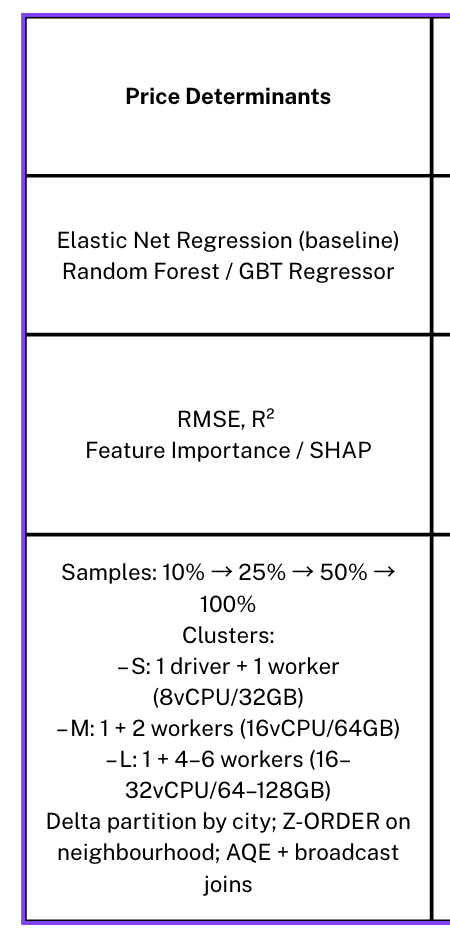

Because the data was preprocessed together for different analysis purposes, some columns that may cause leakage need to be dropped here for model training <br>
drop target related: `price_per_booked_day`, `demand_score`, `occupancy_score` <br>
drop other "dangerous" features: `days_booked`, `booked_ratio` because they are calculated in the same period that the pricing happens.

GBT hyperparameters that will be tuned: <br>

`maxDepth`: controls the maximum depth of each decision tree, determining how complex the tree structure can be. <br>
increae maxDepth -> increases computation time and memory usage, but allows model to learn more complex relationships

`maxIter`: the number of boosting iterations (i.e., the number of trees trained sequentially). <br>
increases maxIter -> increases computation time, but improves predictive performance by reducing bias

`stepSize`: learning rate, determines how much each new tree contributes to the overall model <br>
Smaller stepSize leads to more stable learning and better generalization but takes longer to train. Larger stepSize speeds up convergence but can cause unstable training.

`minInstancesPerNode`: sets the minimum number of samples required in a tree node for a split to be considered. <br>
increases minInstancesPerNode -> reduces overfitting and speeds up training

`minInfoGain`: the minimum information gain required for a split to occur. <br>
Higher values reduce training time and model complexity. Lower values improve accuracy but also increase runtime and the risk of overfitting.

In [ ]:
# train test split
train_df, test_df = df.randomSplit(weights=[0.8, 0.2], seed=42)

In [ ]:
cols_to_use = [c for c in train_df.columns if c not in ["id", "listing_id", "calendar_id", "price"]]

assembler = VectorAssembler(
    inputCols=cols_to_use,
    outputCol="features"
)

train_df_prepared = assembler.transform(train_df)
test_df_prepared = assembler.transform(test_df)

### 10% of total data:

In [ ]:
train_df_10 = assembler.transform(train_df).sample(False, 0.1, seed=42)
train_df_10 = train_df_10.cache()
train_df_10.count()

25/12/12 19:05:24 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
25/12/12 19:05:25 WARN DAGScheduler: Broadcasting large task binary with size 1043.8 KiB
25/12/12 19:05:49 WARN DAGScheduler: Broadcasting large task binary with size 1050.8 KiB


122633

In [ ]:
gbt_10 = GBTRegressor(
    labelCol="price",
    featuresCol="features",

    # tree complexity
    maxDepth=5,
    maxBins=128,         # supports OHE + numeric splits

    # boosting
    maxIter=50,
    stepSize=0.05,       # shrinkage

    # regularization
    minInstancesPerNode=100,
    minInfoGain=1e-4,

    seed=42
)

In [ ]:
model_10 = gbt_10.fit(train_df_10)
model_10.featureImportances

25/12/12 19:28:15 WARN DAGScheduler: Broadcasting large task binary with size 1074.8 KiB
25/12/12 19:28:15 WARN DAGScheduler: Broadcasting large task binary with size 1074.8 KiB
25/12/12 19:28:16 WARN DAGScheduler: Broadcasting large task binary with size 1079.5 KiB
25/12/12 19:28:16 WARN DAGScheduler: Broadcasting large task binary with size 1262.0 KiB
25/12/12 19:28:32 WARN DAGScheduler: Broadcasting large task binary with size 1262.9 KiB
25/12/12 19:28:37 WARN DAGScheduler: Broadcasting large task binary with size 1263.8 KiB
25/12/12 19:28:42 WARN DAGScheduler: Broadcasting large task binary with size 1264.5 KiB
25/12/12 19:28:46 WARN DAGScheduler: Broadcasting large task binary with size 1265.7 KiB
25/12/12 19:28:51 WARN DAGScheduler: Broadcasting large task binary with size 1271.5 KiB
25/12/12 19:29:01 WARN DAGScheduler: Broadcasting large task binary with size 1272.0 KiB
25/12/12 19:29:05 WARN DAGScheduler: Broadcasting large task binary with size 1272.8 KiB
25/12/12 19:29:10 WAR

25/12/12 19:35:11 WARN DAGScheduler: Broadcasting large task binary with size 1335.5 KiB
25/12/12 19:35:16 WARN DAGScheduler: Broadcasting large task binary with size 1336.6 KiB
25/12/12 19:35:20 WARN DAGScheduler: Broadcasting large task binary with size 1337.9 KiB
25/12/12 19:35:25 WARN DAGScheduler: Broadcasting large task binary with size 1339.1 KiB
25/12/12 19:35:36 WARN DAGScheduler: Broadcasting large task binary with size 1339.6 KiB
25/12/12 19:35:41 WARN DAGScheduler: Broadcasting large task binary with size 1340.3 KiB
25/12/12 19:35:45 WARN DAGScheduler: Broadcasting large task binary with size 1341.1 KiB
25/12/12 19:35:50 WARN DAGScheduler: Broadcasting large task binary with size 1342.3 KiB
25/12/12 19:35:55 WARN DAGScheduler: Broadcasting large task binary with size 1343.8 KiB
25/12/12 19:35:57 WARN DAGScheduler: Broadcasting large task binary with size 1316.9 KiB
25/12/12 19:36:08 WARN DAGScheduler: Broadcasting large task binary with size 1344.3 KiB
25/12/12 19:36:15 WAR

25/12/12 19:51:16 WARN DAGScheduler: Broadcasting large task binary with size 1498.8 KiB
25/12/12 19:51:21 WARN DAGScheduler: Broadcasting large task binary with size 1500.0 KiB
25/12/12 19:51:30 WARN DAGScheduler: Broadcasting large task binary with size 1500.6 KiB
25/12/12 19:51:35 WARN DAGScheduler: Broadcasting large task binary with size 1501.3 KiB
25/12/12 19:51:40 WARN DAGScheduler: Broadcasting large task binary with size 1502.1 KiB
25/12/12 19:51:44 WARN DAGScheduler: Broadcasting large task binary with size 1503.3 KiB
25/12/12 19:51:49 WARN DAGScheduler: Broadcasting large task binary with size 1504.7 KiB
25/12/12 19:51:59 WARN DAGScheduler: Broadcasting large task binary with size 1505.2 KiB
25/12/12 19:52:03 WARN DAGScheduler: Broadcasting large task binary with size 1506.0 KiB
25/12/12 19:52:08 WARN DAGScheduler: Broadcasting large task binary with size 1507.0 KiB
25/12/12 19:52:13 WARN DAGScheduler: Broadcasting large task binary with size 1508.8 KiB


SparseVector(6463, {0: 0.0515, 1: 0.0063, 2: 0.066, 4: 0.0045, 5: 0.0009, 6: 0.0123, 7: 0.0013, 8: 0.2445, 9: 0.0443, 10: 0.0191, 11: 0.0014, 12: 0.0052, 13: 0.0247, 14: 0.0051, 15: 0.0123, 16: 0.0237, 17: 0.0391, 18: 0.0001, 42: 0.1267, 58: 0.0, 483: 0.0003, 486: 0.0086, 487: 0.0001, 489: 0.0003, 493: 0.0012, 497: 0.0159, 558: 0.0016, 1328: 0.1304, 1329: 0.03, 1333: 0.0046, 1362: 0.001, 2028: 0.0392, 2029: 0.0, 2032: 0.0268, 4228: 0.0039, 4230: 0.0001, 4232: 0.0, 4236: 0.0455, 4237: 0.0011, 4255: 0.0002, 4262: 0.0})

In [ ]:
gbt_pred = model_10.transform(test_df_prepared)

evaluator = RegressionEvaluator(
    labelCol="price",
    predictionCol="prediction",
    metricName="rmse"
)

rmse_gbt = evaluator.evaluate(gbt_pred)
r2_gbt = RegressionEvaluator(
    labelCol="price",
    predictionCol="prediction",
    metricName="r2"
).evaluate(gbt_pred)

print("GBT RMSE:", rmse_gbt)
print("GBT R^2:", r2_gbt)

25/12/12 19:52:18 WARN DAGScheduler: Broadcasting large task binary with size 1019.7 KiB
25/12/12 19:52:29 WARN DAGScheduler: Broadcasting large task binary with size 1019.7 KiB


GBT RMSE: 603.7247700706773
GBT R^2: 0.2851906862150396


In [ ]:
# save the model
model_10.write().overwrite().save(f"{BUCKET}/models/gbt_10p_2nodes")

25/12/12 20:02:23 WARN DAGScheduler: Broadcasting large task binary with size 1346.7 KiB
25/12/12 20:03:03 WARN DAGScheduler: Broadcasting large task binary with size 1348.7 KiB
25/12/12 20:04:35 WARN DAGScheduler: Broadcasting large task binary with size 1349.2 KiB


### 25% of total data:

In [ ]:
train_df_25 = assembler.transform(train_df).sample(False, 0.25, seed=42)
train_df_25 = train_df_25.cache()
train_df_25.count()

25/12/12 23:25:49 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
25/12/12 23:25:52 WARN DAGScheduler: Broadcasting large task binary with size 1043.8 KiB
25/12/12 23:26:16 WARN DAGScheduler: Broadcasting large task binary with size 1050.8 KiB


307131

In [ ]:
gbt_25 = GBTRegressor(
    labelCol="price",
    featuresCol="features",

    # tree complexity
    maxDepth=6,
    maxBins=128,         # supports OHE + numeric splits

    # boosting
    maxIter=60,          # set a low maxIter for computation time reduction
    stepSize=0.05,       # shrinkage

    # regularization
    minInstancesPerNode=150,
    minInfoGain=1e-4,

    seed=42
)

In [ ]:
model_25 = gbt_25.fit(train_df_25)
model_25.featureImportances

25/12/13 01:53:36 WARN DAGScheduler: Broadcasting large task binary with size 1074.8 KiB
25/12/13 01:53:41 WARN DAGScheduler: Broadcasting large task binary with size 1074.8 KiB
25/12/13 01:53:41 WARN DAGScheduler: Broadcasting large task binary with size 2040.9 KiB
25/12/13 01:53:42 WARN DAGScheduler: Broadcasting large task binary with size 1079.5 KiB
25/12/13 01:53:50 WARN DAGScheduler: Broadcasting large task binary with size 1262.1 KiB
25/12/13 01:53:53 WARN DAGScheduler: Broadcasting large task binary with size 2042.5 KiB
25/12/13 01:54:11 WARN DAGScheduler: Broadcasting large task binary with size 2044.3 KiB
25/12/13 01:54:29 WARN DAGScheduler: Broadcasting large task binary with size 2045.4 KiB
25/12/13 01:54:34 WARN DAGScheduler: Broadcasting large task binary with size 1263.0 KiB
25/12/13 01:54:52 WARN DAGScheduler: Broadcasting large task binary with size 1263.8 KiB
25/12/13 01:54:57 WARN DAGScheduler: Broadcasting large task binary with size 2045.9 KiB
25/12/13 01:55:08 WAR

25/12/13 02:29:37 WARN DAGScheduler: Broadcasting large task binary with size 1424.1 KiB
25/12/13 02:29:47 WARN DAGScheduler: Broadcasting large task binary with size 1425.2 KiB
25/12/13 02:30:11 WARN DAGScheduler: Broadcasting large task binary with size 1425.7 KiB
25/12/13 02:30:21 WARN DAGScheduler: Broadcasting large task binary with size 1426.5 KiB
25/12/13 02:30:32 WARN DAGScheduler: Broadcasting large task binary with size 1427.6 KiB
25/12/13 02:30:42 WARN DAGScheduler: Broadcasting large task binary with size 1429.9 KiB
25/12/13 02:30:53 WARN DAGScheduler: Broadcasting large task binary with size 1432.4 KiB
25/12/13 02:31:04 WARN DAGScheduler: Broadcasting large task binary with size 1432.5 KiB
25/12/13 02:31:27 WARN DAGScheduler: Broadcasting large task binary with size 1433.0 KiB
25/12/13 02:31:38 WARN DAGScheduler: Broadcasting large task binary with size 1433.7 KiB
25/12/13 02:31:48 WARN DAGScheduler: Broadcasting large task binary with size 1434.7 KiB
25/12/13 02:31:59 WAR

25/12/13 03:08:51 WARN DAGScheduler: Broadcasting large task binary with size 1631.9 KiB
25/12/13 03:09:01 WARN DAGScheduler: Broadcasting large task binary with size 1633.9 KiB
25/12/13 03:09:12 WARN DAGScheduler: Broadcasting large task binary with size 1636.0 KiB
25/12/13 03:09:23 WARN DAGScheduler: Broadcasting large task binary with size 1636.2 KiB
25/12/13 03:09:46 WARN DAGScheduler: Broadcasting large task binary with size 1636.7 KiB
25/12/13 03:09:57 WARN DAGScheduler: Broadcasting large task binary with size 1637.5 KiB
25/12/13 03:10:08 WARN DAGScheduler: Broadcasting large task binary with size 1638.5 KiB
25/12/13 03:10:18 WARN DAGScheduler: Broadcasting large task binary with size 1640.0 KiB
25/12/13 03:10:29 WARN DAGScheduler: Broadcasting large task binary with size 1641.9 KiB
25/12/13 03:10:40 WARN DAGScheduler: Broadcasting large task binary with size 1642.9 KiB
25/12/13 03:11:03 WARN DAGScheduler: Broadcasting large task binary with size 1643.4 KiB
25/12/13 03:11:13 WAR

SparseVector(6463, {0: 0.0517, 1: 0.0171, 2: 0.0554, 4: 0.0114, 5: 0.0017, 6: 0.0076, 7: 0.0039, 8: 0.1485, 9: 0.0545, 10: 0.0067, 11: 0.0029, 12: 0.0118, 13: 0.02, 14: 0.0064, 15: 0.1664, 16: 0.0033, 17: 0.0002, 18: 0.0011, 19: 0.0001, 42: 0.0658, 483: 0.0022, 484: 0.0038, 486: 0.0222, 487: 0.0007, 488: 0.0001, 489: 0.0001, 493: 0.0012, 497: 0.1152, 512: 0.0, 523: 0.0, 558: 0.0007, 1328: 0.0187, 1329: 0.0009, 1333: 0.0025, 1362: 0.0001, 2028: 0.1576, 2029: 0.0, 2032: 0.0043, 4228: 0.0002, 4229: 0.0001, 4230: 0.0001, 4232: 0.0001, 4234: 0.0001, 4236: 0.0249, 4237: 0.0054, 4247: 0.0001, 4249: 0.0002, 4255: 0.0002, 4262: 0.0, 4319: 0.0019})

In [ ]:
gbt_25_pred = model_25.transform(test_df_prepared)

evaluator = RegressionEvaluator(
    labelCol="price",
    predictionCol="prediction",
    metricName="rmse"
)

rmse_gbt_25 = evaluator.evaluate(gbt_25_pred)
r2_gbt_25 = RegressionEvaluator(
    labelCol="price",
    predictionCol="prediction",
    metricName="r2"
).evaluate(gbt_25_pred)

print("GBT RMSE:", rmse_gbt_25)
print("GBT R^2:", r2_gbt_25)

25/12/13 03:15:48 WARN DAGScheduler: Broadcasting large task binary with size 1019.7 KiB
25/12/13 03:15:59 WARN DAGScheduler: Broadcasting large task binary with size 1019.7 KiB


GBT RMSE: 571.6131076459043
GBT R^2: 0.389380351116703


In [ ]:
# save the model
model_25.write().overwrite().save(f"{BUCKET}/models/gbt_25p_2nodes")

### 50% of total data:

In [ ]:
train_df_50 = assembler.transform(train_df).sample(False, 0.5, seed=42)
train_df_50 = train_df_50.cache()
train_df_50.count()

25/12/13 16:10:14 WARN DAGScheduler: Broadcasting large task binary with size 1043.8 KiB
25/12/13 16:10:31 WARN DAGScheduler: Broadcasting large task binary with size 1050.8 KiB


612799

In [ ]:
gbt_50 = GBTRegressor(
    labelCol="price",
    featuresCol="features",

    # tree complexity
    maxDepth=8,
    maxBins=64,         # reduce maxBins to reduce computation time

    # boosting
    maxIter=70,
    stepSize=0.03,       # shrinkage

    # regularization
    minInstancesPerNode=200,
    minInfoGain=1e-4,

    seed=42
)

In [ ]:
model_50 = gbt_50.fit(train_df_50)
model_50.featureImportances

25/12/13 16:11:04 WARN DAGScheduler: Broadcasting large task binary with size 1074.8 KiB
25/12/13 16:11:04 WARN DAGScheduler: Broadcasting large task binary with size 1074.8 KiB
25/12/13 16:11:05 WARN DAGScheduler: Broadcasting large task binary with size 1079.6 KiB
25/12/13 16:11:06 WARN DAGScheduler: Broadcasting large task binary with size 1260.3 KiB
25/12/13 16:12:22 WARN DAGScheduler: Broadcasting large task binary with size 1261.2 KiB
25/12/13 16:12:43 WARN DAGScheduler: Broadcasting large task binary with size 1262.1 KiB
25/12/13 16:13:04 WARN DAGScheduler: Broadcasting large task binary with size 1263.0 KiB
25/12/13 16:13:25 WARN DAGScheduler: Broadcasting large task binary with size 1264.8 KiB
25/12/13 16:13:45 WARN DAGScheduler: Broadcasting large task binary with size 1266.9 KiB
25/12/13 16:14:06 WARN DAGScheduler: Broadcasting large task binary with size 1269.9 KiB
25/12/13 16:14:27 WARN DAGScheduler: Broadcasting large task binary with size 1274.6 KiB
25/12/13 16:14:48 WAR

25/12/13 17:24:40 WARN DAGScheduler: Broadcasting large task binary with size 1480.2 KiB
25/12/13 17:25:01 WARN DAGScheduler: Broadcasting large task binary with size 1482.5 KiB
25/12/13 17:25:22 WARN DAGScheduler: Broadcasting large task binary with size 1484.5 KiB
25/12/13 17:25:43 WARN DAGScheduler: Broadcasting large task binary with size 1482.4 KiB
25/12/13 17:26:31 WARN DAGScheduler: Broadcasting large task binary with size 1482.9 KiB
25/12/13 17:26:52 WARN DAGScheduler: Broadcasting large task binary with size 1483.7 KiB
25/12/13 17:27:13 WARN DAGScheduler: Broadcasting large task binary with size 1484.7 KiB
25/12/13 17:27:34 WARN DAGScheduler: Broadcasting large task binary with size 1486.5 KiB
25/12/13 17:27:54 WARN DAGScheduler: Broadcasting large task binary with size 1489.5 KiB
25/12/13 17:28:16 WARN DAGScheduler: Broadcasting large task binary with size 1492.7 KiB
25/12/13 17:28:37 WARN DAGScheduler: Broadcasting large task binary with size 1495.7 KiB
25/12/13 17:28:59 WAR

25/12/13 18:54:55 WARN DAGScheduler: Broadcasting large task binary with size 1781.7 KiB
25/12/13 18:55:17 WARN DAGScheduler: Broadcasting large task binary with size 1784.3 KiB
25/12/13 18:55:37 WARN DAGScheduler: Broadcasting large task binary with size 1787.4 KiB
25/12/13 18:55:59 WARN DAGScheduler: Broadcasting large task binary with size 1785.3 KiB
25/12/13 18:56:46 WARN DAGScheduler: Broadcasting large task binary with size 1785.8 KiB
25/12/13 18:57:07 WARN DAGScheduler: Broadcasting large task binary with size 1786.6 KiB
25/12/13 18:57:28 WARN DAGScheduler: Broadcasting large task binary with size 1787.6 KiB
25/12/13 18:57:48 WARN DAGScheduler: Broadcasting large task binary with size 1788.9 KiB
25/12/13 18:58:09 WARN DAGScheduler: Broadcasting large task binary with size 1791.3 KiB
25/12/13 18:58:30 WARN DAGScheduler: Broadcasting large task binary with size 1793.9 KiB
25/12/13 18:58:51 WARN DAGScheduler: Broadcasting large task binary with size 1797.0 KiB
25/12/13 18:59:13 WAR

In [ ]:
gbt_50_pred = model_50.transform(test_df_prepared)

evaluator = RegressionEvaluator(
    labelCol="price",
    predictionCol="prediction",
    metricName="rmse"
)

rmse_gbt_50 = evaluator.evaluate(gbt_50_pred)
r2_gbt_50 = RegressionEvaluator(
    labelCol="price",
    predictionCol="prediction",
    metricName="r2"
).evaluate(gbt_50_pred)

print("GBT RMSE:", rmse_gbt_50)
print("GBT R^2:", r2_gbt_50)

25/12/14 01:08:06 WARN DAGScheduler: Broadcasting large task binary with size 1019.7 KiB
25/12/14 01:08:20 WARN DAGScheduler: Broadcasting large task binary with size 1019.7 KiB


GBT RMSE: 550.0866773007735
GBT R^2: 0.43450512845351463


In [ ]:
# save the model
model_50.write().overwrite().save(f"{BUCKET}/models/gbt_50p_2nodes")

### 100% of total data:

In [ ]:
train_df_100 = assembler.transform(train_df)
train_df_100 = train_df_100.cache()
train_df_100.count()

25/12/14 01:12:03 WARN DAGScheduler: Broadcasting large task binary with size 1026.8 KiB
25/12/14 01:12:18 WARN DAGScheduler: Broadcasting large task binary with size 1033.8 KiB


1223207

In [ ]:
gbt_100 = GBTRegressor(
    labelCol="price",
    featuresCol="features",
    maxDepth=8,
    maxBins=64,
    maxIter=70,
    stepSize=0.02,
    minInstancesPerNode=250,
    minInfoGain=5e-4,
    seed=42
)

In [ ]:
model_100 = gbt_100.fit(train_df_100)
model_100.featureImportances

25/12/14 16:57:08 WARN DAGScheduler: Broadcasting large task binary with size 1057.8 KiB
25/12/14 16:57:09 WARN DAGScheduler: Broadcasting large task binary with size 1057.8 KiB
25/12/14 16:57:10 WARN DAGScheduler: Broadcasting large task binary with size 1062.6 KiB
25/12/14 16:57:11 WARN DAGScheduler: Broadcasting large task binary with size 1243.3 KiB
25/12/14 16:59:55 WARN DAGScheduler: Broadcasting large task binary with size 1244.2 KiB
25/12/14 17:00:36 WARN DAGScheduler: Broadcasting large task binary with size 1245.0 KiB
25/12/14 17:01:17 WARN DAGScheduler: Broadcasting large task binary with size 1246.0 KiB
25/12/14 17:01:58 WARN DAGScheduler: Broadcasting large task binary with size 1248.0 KiB
25/12/14 17:02:39 WARN DAGScheduler: Broadcasting large task binary with size 1251.0 KiB
25/12/14 17:03:20 WARN DAGScheduler: Broadcasting large task binary with size 1254.1 KiB
25/12/14 17:04:02 WARN DAGScheduler: Broadcasting large task binary with size 1259.1 KiB
25/12/14 17:04:44 WAR

25/12/14 18:09:30 WARN DAGScheduler: Broadcasting large task binary with size 1385.9 KiB
25/12/14 18:10:11 WARN DAGScheduler: Broadcasting large task binary with size 1386.6 KiB
25/12/14 18:10:52 WARN DAGScheduler: Broadcasting large task binary with size 1387.7 KiB
25/12/14 18:11:33 WARN DAGScheduler: Broadcasting large task binary with size 1389.7 KiB
25/12/14 18:12:14 WARN DAGScheduler: Broadcasting large task binary with size 1392.4 KiB
25/12/14 18:12:54 WARN DAGScheduler: Broadcasting large task binary with size 1396.4 KiB
25/12/14 18:13:36 WARN DAGScheduler: Broadcasting large task binary with size 1401.0 KiB
25/12/14 18:14:18 WARN DAGScheduler: Broadcasting large task binary with size 1399.0 KiB
25/12/14 18:15:49 WARN DAGScheduler: Broadcasting large task binary with size 1399.5 KiB
25/12/14 18:16:31 WARN DAGScheduler: Broadcasting large task binary with size 1400.3 KiB
25/12/14 18:17:12 WARN DAGScheduler: Broadcasting large task binary with size 1401.4 KiB
25/12/14 18:17:53 WAR

25/12/14 19:21:56 WARN DAGScheduler: Broadcasting large task binary with size 1519.9 KiB
25/12/14 19:22:37 WARN DAGScheduler: Broadcasting large task binary with size 1522.7 KiB
25/12/14 19:23:18 WARN DAGScheduler: Broadcasting large task binary with size 1526.6 KiB
25/12/14 19:23:59 WARN DAGScheduler: Broadcasting large task binary with size 1525.6 KiB
25/12/14 19:25:32 WARN DAGScheduler: Broadcasting large task binary with size 1526.1 KiB
25/12/14 19:26:12 WARN DAGScheduler: Broadcasting large task binary with size 1526.9 KiB
25/12/14 19:26:53 WARN DAGScheduler: Broadcasting large task binary with size 1527.6 KiB
25/12/14 19:27:34 WARN DAGScheduler: Broadcasting large task binary with size 1529.1 KiB
25/12/14 19:28:15 WARN DAGScheduler: Broadcasting large task binary with size 1531.0 KiB
25/12/14 19:28:56 WARN DAGScheduler: Broadcasting large task binary with size 1533.2 KiB
25/12/14 19:29:38 WARN DAGScheduler: Broadcasting large task binary with size 1536.3 KiB
25/12/14 19:30:21 WAR

25/12/14 20:35:11 WARN DAGScheduler: Broadcasting large task binary with size 1648.4 KiB
25/12/14 20:35:51 WARN DAGScheduler: Broadcasting large task binary with size 1649.2 KiB
25/12/14 20:36:32 WARN DAGScheduler: Broadcasting large task binary with size 1650.2 KiB
25/12/14 20:37:13 WARN DAGScheduler: Broadcasting large task binary with size 1652.3 KiB
25/12/14 20:37:54 WARN DAGScheduler: Broadcasting large task binary with size 1654.5 KiB
25/12/14 20:38:35 WARN DAGScheduler: Broadcasting large task binary with size 1656.8 KiB
25/12/14 20:39:16 WARN DAGScheduler: Broadcasting large task binary with size 1660.2 KiB
25/12/14 20:39:58 WARN DAGScheduler: Broadcasting large task binary with size 1658.8 KiB
25/12/14 20:41:30 WARN DAGScheduler: Broadcasting large task binary with size 1659.3 KiB
25/12/14 20:42:11 WARN DAGScheduler: Broadcasting large task binary with size 1660.1 KiB
25/12/14 20:42:52 WARN DAGScheduler: Broadcasting large task binary with size 1660.8 KiB
25/12/14 20:43:33 WAR

25/12/15 00:18:21 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/12/15 00:19:02 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/12/15 00:19:44 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/12/15 00:20:25 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB


SparseVector(6463, {0: 0.017, 1: 0.0, 2: 0.084, 3: 0.0, 4: 0.0052, 5: 0.0012, 6: 0.0063, 7: 0.0032, 8: 0.0883, 9: 0.2226, 10: 0.0031, 11: 0.0033, 12: 0.0428, 13: 0.174, 14: 0.015, 15: 0.072, 16: 0.0026, 17: 0.0009, 18: 0.0048, 19: 0.0, 23: 0.0, 26: 0.0, 42: 0.0336, 483: 0.0008, 484: 0.0001, 485: 0.0, 486: 0.0025, 487: 0.0004, 488: 0.0, 489: 0.0003, 493: 0.0004, 494: 0.0003, 497: 0.0027, 512: 0.0, 517: 0.0001, 540: 0.0, 541: 0.0, 558: 0.0034, 1328: 0.0055, 1329: 0.0522, 1333: 0.0, 2028: 0.0781, 2029: 0.0001, 2032: 0.0, 2050: 0.0003, 2114: 0.0, 4228: 0.0, 4229: 0.0459, 4230: 0.0001, 4233: 0.0001, 4234: 0.002, 4235: 0.0, 4236: 0.0138, 4237: 0.0019, 4247: 0.0001, 4249: 0.0, 4252: 0.0001, 4255: 0.0002, 4261: 0.0001, 4262: 0.0002, 4298: 0.0002, 4319: 0.0008, 4320: 0.0003, 4321: 0.0012, 4325: 0.0026, 4332: 0.0004, 4333: 0.0001, 4334: 0.0002, 4394: 0.0025})

In [ ]:
gbt_100_pred = model_100.transform(test_df_prepared)

evaluator = RegressionEvaluator(
    labelCol="price",
    predictionCol="prediction",
    metricName="rmse"
)

rmse_gbt_100 = evaluator.evaluate(gbt_100_pred)
r2_gbt_100 = RegressionEvaluator(
    labelCol="price",
    predictionCol="prediction",
    metricName="r2"
).evaluate(gbt_100_pred)

print("GBT RMSE:", rmse_gbt_100)
print("GBT R^2:", r2_gbt_100)

25/12/15 00:27:35 WARN DAGScheduler: Broadcasting large task binary with size 1019.7 KiB
25/12/15 00:27:46 WARN DAGScheduler: Broadcasting large task binary with size 1019.7 KiB


GBT RMSE: 539.2886282126607
GBT R^2: 0.4564882439084361


In [ ]:
# save the model
model_100.write().overwrite().save(f"{BUCKET}/models/gbt_100p_2nodes")

### 2 Nodes Result Table: <br>
| Percent of Data | RMSE  | $R^2$ |
|-----------------|-------|-------|
| 10%             | 603.72| 0.2852|
| 25%             | 571.61| 0.3894|
| 50%             | 550.09| 0.4345|
| 100%            | 539.29| 0.4565|

Monatomic improvement with increasing data: As the percentage of data increases, the $R^{2}$ increases and RMSE decreases. This steady improvement demonstrates that the GBT model performs better than the baseline linear regression model in general, with no fluctuations in the performance increase.


Performance increase ceiling: As the percentage approaches 100%, the model performance's improvement gets smaller and smaller. This shows a ceiling in performance with existing data and features.


Noise-limited prediction: Though in the end, all of the data was used for training, the $R^{2}$ still reaches less than 50%, meaning than less than half of the variance in price can be explained with existing data. This is caused by the fact that Airbnb dataset is quite noisy, which makes it hard to explain one variable based on the other variables.